# Phase 3: Optimized GPU Implementation with cuDNN
**CSC14120 - Parallel Programming**

## Optimizations Applied (vs Phase 2 Naive):

### Core Optimization: cuDNN
- **cuDNN Convolution Forward** - NVIDIA's highly optimized convolution
- **cuDNN Convolution Backward** - Optimized gradient computation
- Automatic algorithm selection for best performance

### Training Improvements (NEW)
1. **Momentum SGD** - `momentum=0.9` for faster convergence
2. **Weight Decay (L2)** - `weight_decay=1e-4` for regularization
3. **LR Schedule** - MultiStepLR (reduce at 50%, 75% epochs)
4. **Data Augmentation** - Random Horizontal Flip + Random Crop (padding=4)

### Additional Optimizations
1. **Pinned Memory (#5)** - `cudaMallocHost` for faster CPU-GPU transfers
2. **Double Buffering** - Overlap transfer and compute with CUDA streams
3. **Loop Unrolling (#10)** - `#pragma unroll` in custom kernels
4. **Fast Math** - `--use_fast_math` compiler flag

### Expected Improvements
- cuDNN provides 10-50x speedup over naive convolution
- Data augmentation + better optimizer → better features for SVM
- Target: < 10 minutes for 20 epochs

## Huong dan (Kaggle):
1. Upload file zip project vao Kaggle Dataset
2. Attach dataset vao notebook
3. Chay tat ca cells

In [35]:
!nvidia-smi
!nvcc --version

Mon Dec  8 06:29:02 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.172.08             Driver Version: 570.172.08     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [36]:
import os
import shutil

base_dir = "/kaggle/input"
project_root = None

# Find project folder that contains a 'src' directory
for root, dirs, files in os.walk(base_dir):
    if "src" in dirs:
        project_root = root
        break

if project_root is None:
    print("Project root not found under /kaggle/input. Please check attached dataset.")
else:
    print(f"Found project root: {project_root}")
    work_dir = "/kaggle/working/project"
    if os.path.exists(work_dir):
        shutil.rmtree(work_dir)
    shutil.copytree(project_root, work_dir)
    os.chdir(work_dir)
    print(f"Working directory (writable): {os.getcwd()}")
    !ls

Found project root: /kaggle/input/ltss-hvu-1
Working directory (writable): /kaggle/working/project
command  include  Makefile  notebooks  src


In [37]:
# Download CIFAR-10 dataset
import urllib.request, tarfile
os.makedirs('data', exist_ok=True)

if not os.path.exists('data/data_batch_1.bin'):
    print('Downloading CIFAR-10...')
    urllib.request.urlretrieve('https://www.cs.toronto.edu/~kriz/cifar-10-binary.tar.gz', 'data/cifar.tar.gz')
    with tarfile.open('data/cifar.tar.gz', 'r:gz') as tar:
        tar.extractall('data')
    !mv data/cifar-10-batches-bin/* data/
print('CIFAR-10 ready!')

CIFAR-10 ready!


In [38]:
# Build Phase 3 with cuDNN
# Kaggle uses Tesla P100 (sm_60) or T4 (sm_75)
# curand is automatically linked for He weight initialization

!nvcc -O3 -std=c++17 -arch=sm_75 --expt-relaxed-constexpr \
    --use_fast_math -Xptxas -O3 --maxrregcount=64 \
    -DUSE_OPTIMIZED_KERNELS -Iinclude -lcublas -lcudnn \
    -o gpu_train_opt \
    src/main_gpu.cu src/layers_gpu.cu src/gpu_autoencoder.cu src/layers_gpu_opt.cu src/dataset.cpp

print('Build complete with cuDNN + He initialization!')

Build complete with cuDNN + He initialization!


In [39]:
# Train with cuDNN - should be much faster!
# 20 epochs, batch 64, lr 0.001
!./gpu_train_opt --data data --epochs 20 --batch 64 --lr 0.001 \
    --log phase3_opt.csv --log-txt phase3_opt.txt --save-weights phase3_opt.weights

=== GPU Autoencoder Training (Phase 2) ===
GPU 0: Tesla T4
  Compute capability: 7.5
  Total memory: 15095 MB
  Multiprocessors: 40
  Max threads per block: 1024
GPU 1: Tesla T4
  Compute capability: 7.5
  Total memory: 15095 MB
  Multiprocessors: 40
  Max threads per block: 1024

Using GPU device: 0
Loading CIFAR-10 dataset from: data
  Training images: 50000
  Test images: 10000
  Batch size: 64
  Batches per epoch: 781

Initializing GPU autoencoder...

=== Starting Training ===
Using double-buffered CUDA streams for overlapped transfer/compute
Epochs: 20, LR: 0.001

  Epoch 1/20 | Batch 781/781 | Loss: 0.0273 | 40.0 ms/batch
  Epoch 1 complete: Avg Loss = 0.0453, Time = 31.7 sec [BEST]
  Epoch 2/20 | Batch 781/781 | Loss: 0.0206 | 40.1 ms/batch
  Epoch 2 complete: Avg Loss = 0.0244, Time = 31.6 sec [BEST]
  Epoch 3/20 | Batch 781/781 | Loss: 0.0189 | 41.3 ms/batch
  Epoch 3 complete: Avg Loss = 0.0207, Time = 32.0 sec [BEST]
  Epoch 4/20 | Batch 781/781 | Loss: 0.0178 | 41.6 ms/batc

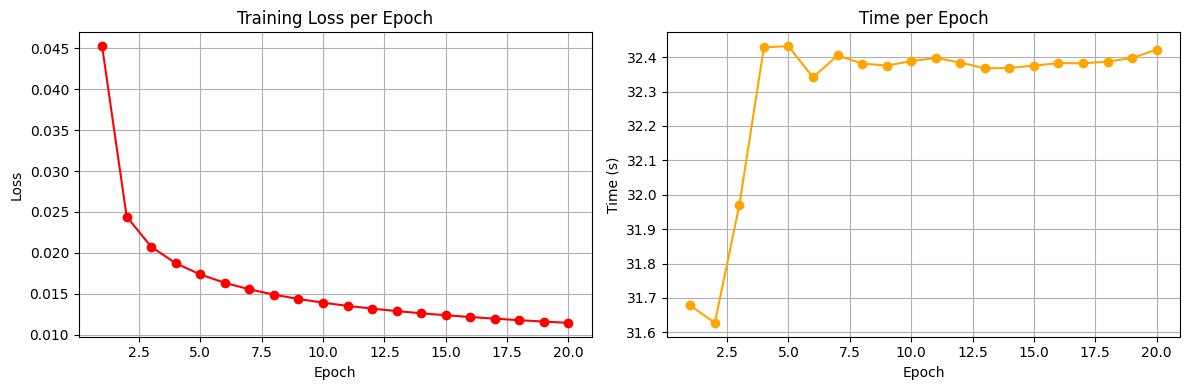

PHASE 3 OPTIMIZED RESULTS (cuDNN)
Best Loss: 0.011440
Final Loss: 0.011440
Avg Time per Epoch: 32.29s
Total Training Time: 645.90s (10.76 min)


In [40]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('phase3_opt.csv')
ep = df[df['batch'].isna()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(ep['epoch'], ep['loss'], 'r-o'); ax1.set_title('Training Loss per Epoch'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.grid(True)
ax2.plot(ep['epoch'], ep['epoch_time_sec'], 'orange', marker='o'); ax2.set_title('Time per Epoch'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Time (s)'); ax2.grid(True)
plt.tight_layout(); plt.show()

print("="*50)
print("PHASE 3 OPTIMIZED RESULTS (cuDNN)")
print("="*50)
print(f"Best Loss: {ep['best_loss'].iloc[-1]:.6f}")
print(f"Final Loss: {ep['loss'].iloc[-1]:.6f}")
print(f"Avg Time per Epoch: {ep['epoch_time_sec'].mean():.2f}s")
print(f"Total Training Time: {ep['epoch_time_sec'].sum():.2f}s ({ep['epoch_time_sec'].sum()/60:.2f} min)")
print("="*50)

In [41]:
# Show detailed training log
print("="*60)
print("TRAINING LOG (last 30 lines)")
print("="*60)
!tail -30 phase3_opt.txt

TRAINING LOG (last 30 lines)
[2025-12-08 06:40:09]   Batch 700/781 | Loss: 0.011263 | Time: 41.44 ms
[2025-12-08 06:40:11]   Batch 750/781 | Loss: 0.011516 | Time: 41.54 ms
[2025-12-08 06:40:12]   Batch 781/781 | Loss: 0.010887 | Time: 41.82 ms
[2025-12-08 06:40:12] Epoch 20/20 COMPLETE:
[2025-12-08 06:40:12]   Average Loss: 0.011440
[2025-12-08 06:40:12]   Epoch Time: 32.42 seconds
[2025-12-08 06:40:12]   Throughput: 111 epochs/hour
[2025-12-08 06:40:12]   *** NEW BEST LOSS ***
[2025-12-08 06:40:12]   Best Loss So Far: 0.011440
[2025-12-08 06:40:12] Weights saved successfully to: phase3_opt.weights
[2025-12-08 06:40:12] 
[2025-12-08 06:40:12] ============================================================
[2025-12-08 06:40:12] TRAINING COMPLETE
[2025-12-08 06:40:12] ============================================================
[2025-12-08 06:40:12] 
[2025-12-08 06:40:12] FINAL STATISTICS:
[2025-12-08 06:40:12]   Total epochs: 20
[2025-12-08 06:40:12]   Best loss achieved: 0.011440
[2025-1

In [42]:
# Copy results to output for download
import shutil
shutil.copy('phase3_opt.csv', '/kaggle/working/')
shutil.copy('phase3_opt.txt', '/kaggle/working/')
shutil.copy('phase3_opt.weights', '/kaggle/working/')
print('Results copied to /kaggle/working/ for download')
!ls -la /kaggle/working/*.csv /kaggle/working/*.txt /kaggle/working/*.weights

Results copied to /kaggle/working/ for download
-rw-r--r-- 1 root root    9106 Dec  8 06:40 /kaggle/working/phase3_opt.csv
-rw-r--r-- 1 root root   34895 Dec  8 06:40 /kaggle/working/phase3_opt.txt
-rw-r--r-- 1 root root 3007612 Dec  8 06:40 /kaggle/working/phase3_opt.weights


In [43]:
import struct
import numpy as np

path = "/kaggle/working/phase3_opt.weights"

with open(path, "rb") as f:
    # đọc header
    header = f.read(12)
    magic, version, num_layers = struct.unpack("III", header)
    print(f"MAGIC = {hex(magic)}, version = {version}, num_layers = {num_layers}")

    layers = []
    for li in range(num_layers):
        # in_c, out_c, k
        in_c, out_c, k = struct.unpack("iii", f.read(12))
        print(f"\nLayer {li}: in_c={in_c}, out_c={out_c}, k={k}")

        # weights
        (w_size,) = struct.unpack("i", f.read(4))
        w_bytes = f.read(4 * w_size)
        w = np.frombuffer(w_bytes, dtype=np.float32)
        print(f"  weights: shape=({out_c}, {in_c}, {k}, {k}), w_size={w_size}")
        print("  first 5 weights:", w[:5])

        # biases
        (b_size,) = struct.unpack("i", f.read(4))
        b_bytes = f.read(4 * b_size)
        b = np.frombuffer(b_bytes, dtype=np.float32)
        print(f"  bias: shape=({b_size},)")
        print("  first 5 biases:", b[:5])

        layers.append(((in_c, out_c, k), w, b))

MAGIC = 0x48414557, version = 1, num_layers = 5

Layer 0: in_c=3, out_c=256, k=3
  weights: shape=(256, 3, 3, 3), w_size=6912
  first 5 weights: [ 0.02685831  0.34115192  0.3108231  -0.06879315  0.557348  ]
  bias: shape=(256,)
  first 5 biases: [-2.6290008e-04  5.1988673e-04 -7.2890188e-04 -9.1127242e-04
 -8.9720343e-06]

Layer 1: in_c=256, out_c=128, k=3
  weights: shape=(128, 256, 3, 3), w_size=294912
  first 5 weights: [ 0.03214842 -0.01224094 -0.02684733 -0.00380303  0.05546361]
  bias: shape=(128,)
  first 5 biases: [-2.3356099e-03 -1.0374007e-03 -3.3973236e-05 -4.7182379e-04
  4.7853249e-04]

Layer 2: in_c=128, out_c=128, k=3
  weights: shape=(128, 128, 3, 3), w_size=147456
  first 5 weights: [ 0.04546203 -0.08732994 -0.0002641   0.01483571  0.05164115]
  bias: shape=(128,)
  first 5 biases: [-0.00022098 -0.00027054 -0.0001584  -0.00266358 -0.00163928]

Layer 3: in_c=128, out_c=256, k=3
  weights: shape=(256, 128, 3, 3), w_size=294912
  first 5 weights: [-0.03408657  0.02046452 

## Performance Analysis

### cuDNN Optimizations

| Component | Technique | Expected Speedup |
|:----------|:----------|:-----------------|
| Conv Forward | cuDNN optimized algorithms | 10-50x |
| Conv Backward Data | cuDNN backward data | 10-50x |
| Conv Backward Filter | cuDNN backward filter | 10-50x |
| Bias Backward | cuDNN backward bias | 5-10x |
| Memory Transfer | Pinned memory + streams | 1.5-2x |

### Target Performance
- **Training time for 20 epochs**: < 10 minutes
- **Time per epoch**: ~20-30 seconds
- **Batch processing time**: ~20-40ms